# Exploratory Data Analysis (EDA)
Before we build any machine learning model, we need to understand our data.
Here, we will look at our data from many angles; one column at a time (univariate),
two columns at a time (bivariate), and many columns together (multivariate).

Our dataset is made up of songs from 1950–2019 with lyrical feature scores (0–1 scale) for themes
like romance, violence, gospel, sadness, etc.

In [15]:
##Importing the neccessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Loading the dataset

df = pd.read_csv('/Users/sa03/Desktop/Music Recommendation Algorithm/Dataset/music_rec/train.csv')

In [17]:
#Lets look at the first 5 rows of the dataset

df.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


In [18]:
# Checking the column types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

We see that our dataset has no null values. Our dataset has a mix of both int,float and object data types. 
The column Unnamed seems to be the index for the songs when the data was captured so i am going to rename that and set it to song_id

In [19]:
#Renaming the unnamed column to 'song_id' and setting it as the index of the dataframe

df.rename(columns={'Unnamed: 0': 'song_id'}, inplace=True)
df.set_index('song_id', inplace=True)

In [20]:
# Finding the statistical summary of all the numerical columns

df.describe().round(4)

,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000,28362.0000
mean,1990.2397,73.0305,0.0211,0.1184,0.1210,0.0574,0.0174,0.0170,0.0487,0.0767,0.0972,0.0601,0.0474,0.0490,0.0242,0.1294,0.0310,0.4251
std,18.4870,41.8316,0.0524,0.1787,0.1722,0.1119,0.0407,0.0420,0.1061,0.1095,0.1813,0.1233,0.0916,0.0896,0.0510,0.1811,0.0717,0.2641
min,1950.0000,1.0000,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0143
25%,1975.0000,42.0000,0.0009,0.0011,0.0012,0.0010,0.0010,0.0009,0.0010,0.0011,0.0011,0.0010,0.0010,0.0010,0.0010,0.0011,0.0010,0.1857
50%,1991.0000,63.0000,0.0015,0.0025,0.0066,0.0019,0.0016,0.0015,0.0018,0.0026,0.0018,0.0018,0.0016,0.0018,0.0016,0.0053,0.0018,0.4143
75%,2007.0000,93.0000,0.0040,0.1925,0.1979,0.0658,0.0100,0.0048,0.0423,0.1321,0.0888,0.0551,0.0544,0.0643,0.0255,0.2351,0.0326,0.6429
max,2019.0000,199.0000,0.6477,0.9818,0.9621,0.9737,0.4975,0.5453,0.9408,0.6458,0.9923,0.9569,0.6380,0.6678,0.6181,0.9814,0.9588,1.0000


## Univariate Analysis
Our goal here is to study one variable at a time to understand its distribution

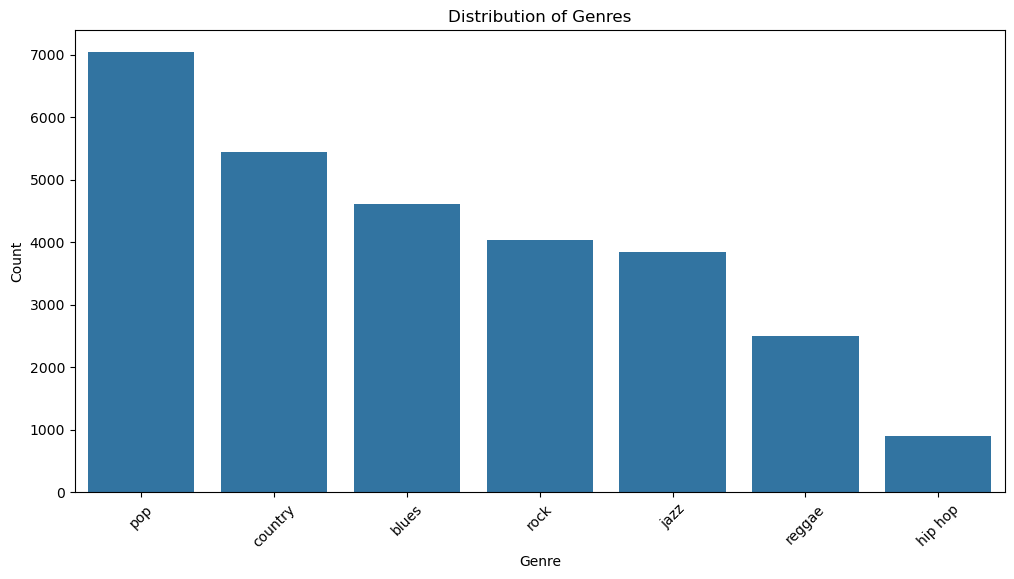

In [21]:
## Genre distribution
# Let us explore how many genres are there in the dataset and how they are distributed. We will use a countplot to visualize the distribution of genres.

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='genre', order=df['genre'].value_counts().index
)
plt.title('Distribution of Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()  


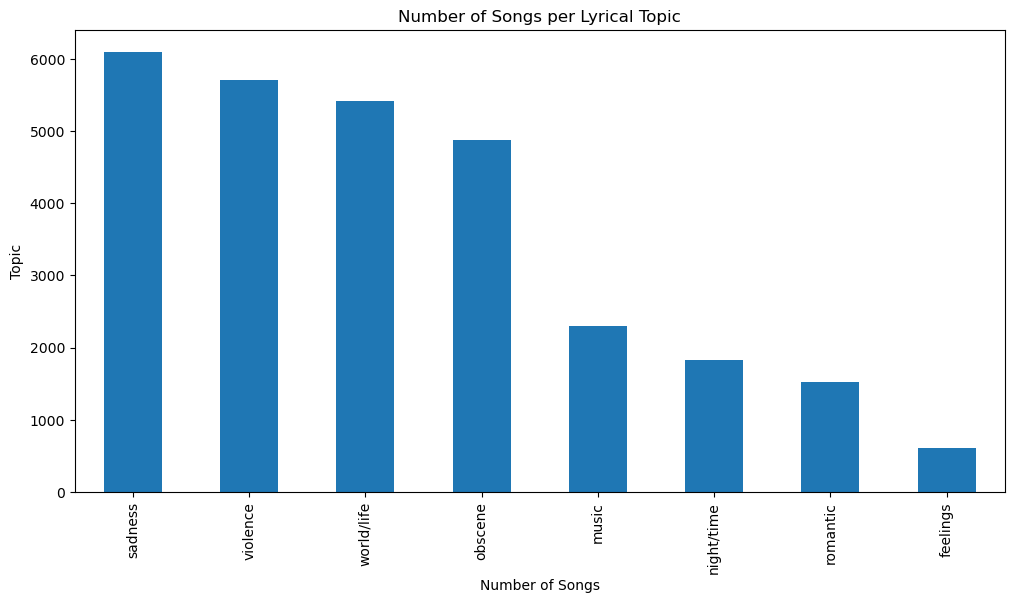

In [23]:
# Lyrical Topic Distribution
# Next, we will explore the distribution of lyrical topics in the dataset. Similar to genres, we will use a countplot to visualize the distribution of lyrical topics.  

plt.figure(figsize=(12, 6))

topic_counts = df['topic'].value_counts()

topic_counts.plot(kind='bar')

plt.title('Number of Songs per Lyrical Topic')
plt.xlabel('Number of Songs')
plt.ylabel('Topic')
plt.tight_layout
plt.show()

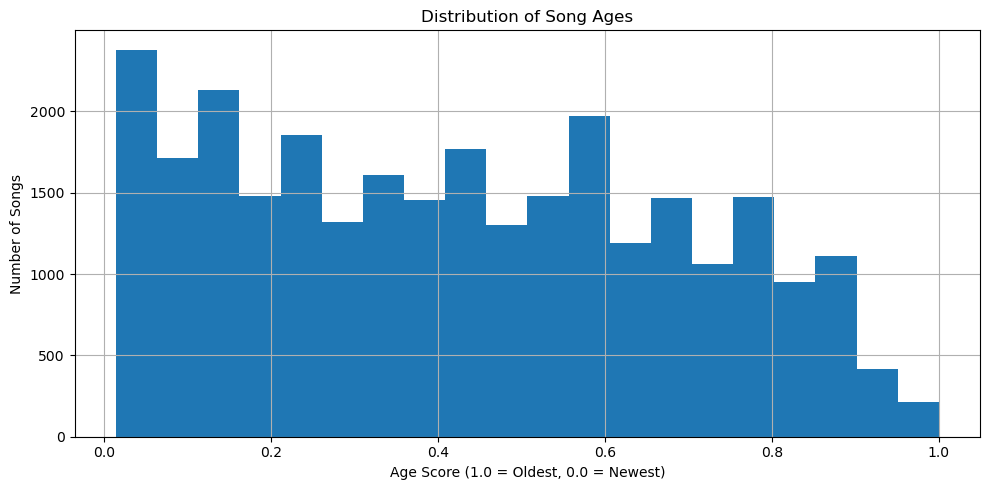

In [26]:
# Now lets explore the song age distribution. We will use a histogram to visualize the distribution of song ages in the dataset.
# 1.0 = oldest song, 0.0 = newest song

df['age'].hist(bins=20, figsize=(10, 5))  

plt.title('Distribution of Song Ages')
plt.xlabel('Age Score (1.0 = Oldest, 0.0 = Newest)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()


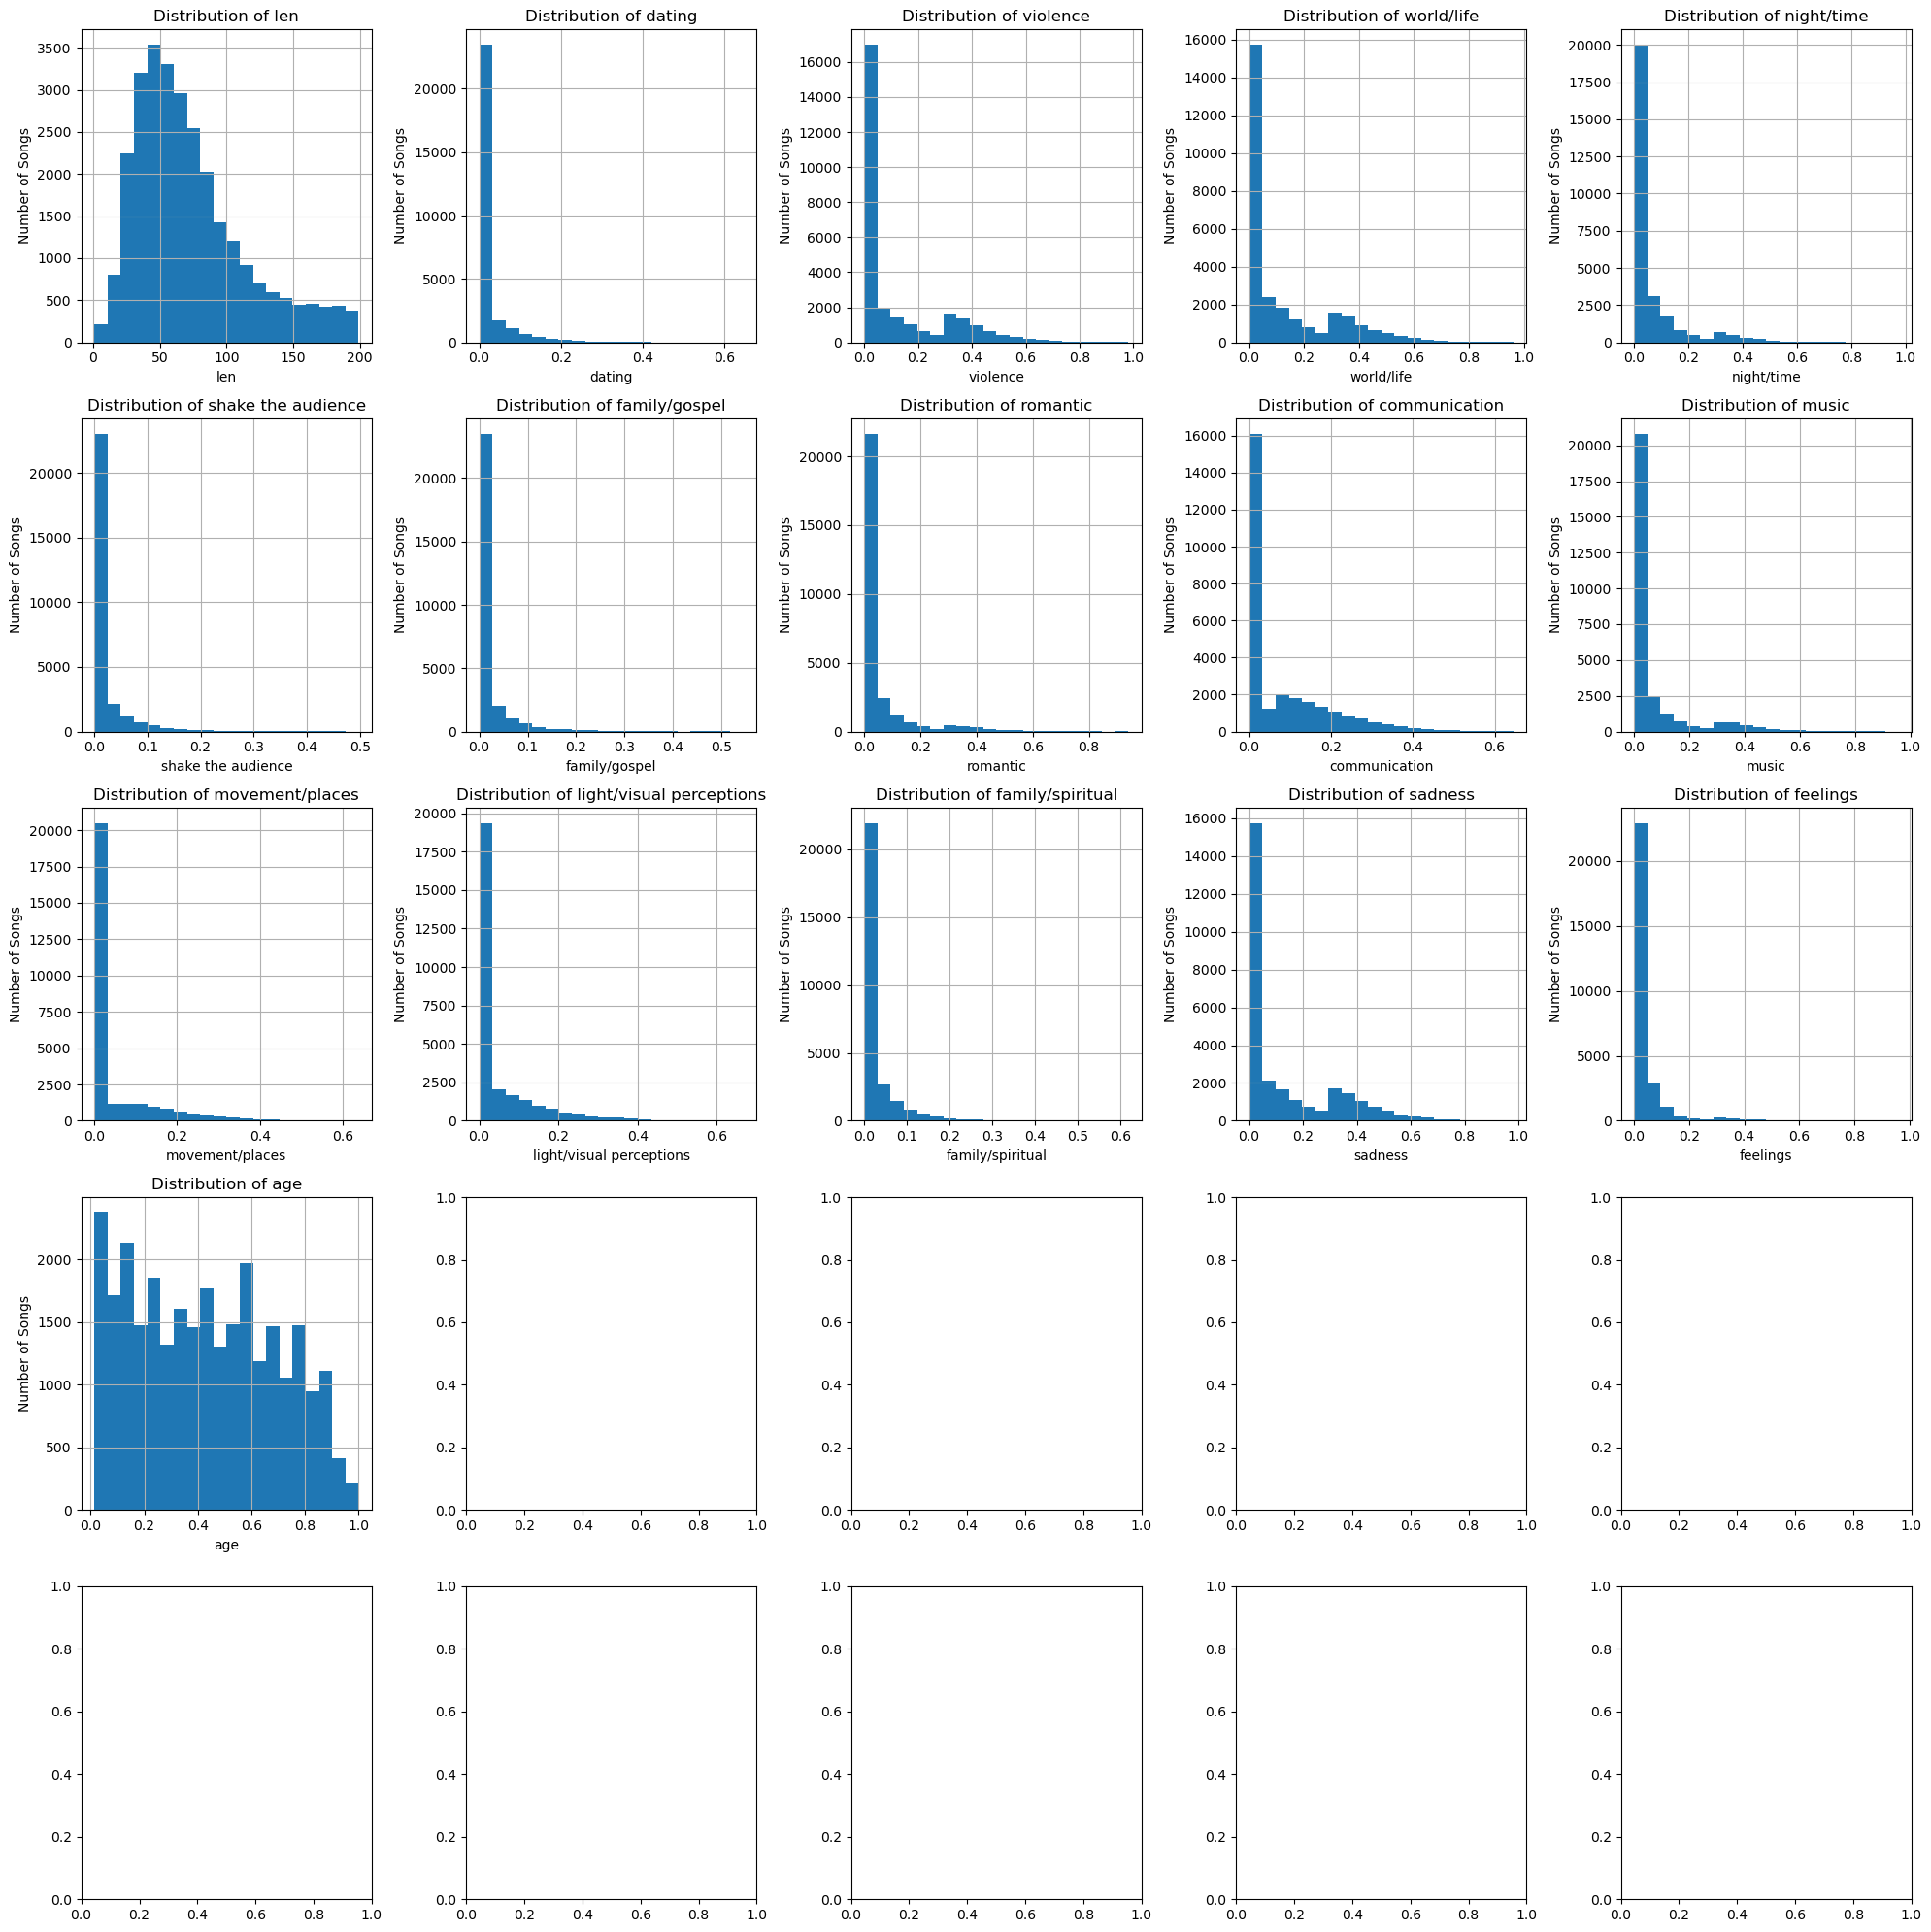

In [39]:
#Lets explore a distribution of each lyric score feature. We will use histograms to visualize the distribution of each lyric score feature in the dataset.

#First let us define the numerical features we want to explore

score_cols = ['len','dating','violence','world/life','night/time','shake the audience','family/gospel','romantic','communication','music','movement/places','light/visual perceptions','family/spiritual','sadness','feelings','age']

#Now we will create a grid of histograms for each of these features- one per column
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))  
axes = axes.flatten()

for i, col in enumerate(score_cols):
    df[col].hist(ax=axes[i], bins=20)  
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Songs')   
plt.tight_layout()
plt.show()


## Bivariate Analysis
### Now let us explore two variables at a time to see how they relate 

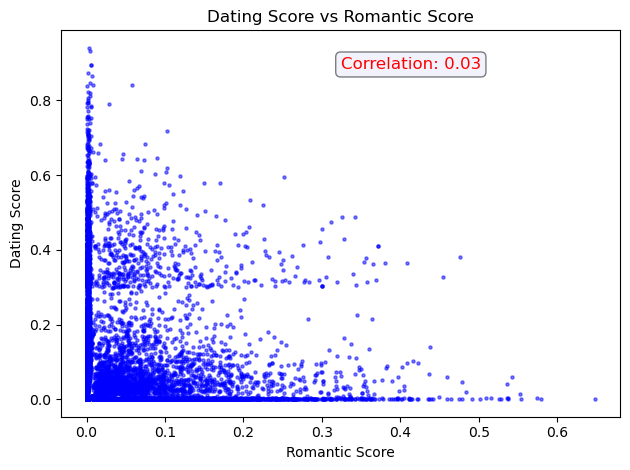

In [48]:
# lets explore romantic and dating score.

plt.scatter(df['dating'], df['romantic'], alpha=0.5, color='blue',s=5)

plt.title('Dating Score vs Romantic Score')
plt.xlabel('Romantic Score')
plt.ylabel('Dating Score')

#lets add the actual correlation coefficient to the plot

r = df['dating'].corr(df['romantic'])
plt.text(0.5, 0.9, f'Correlation: {r:.2f}', transform=plt.gca().transAxes, fontsize=12, color='red',bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))
plt.tight_layout()
plt.show()

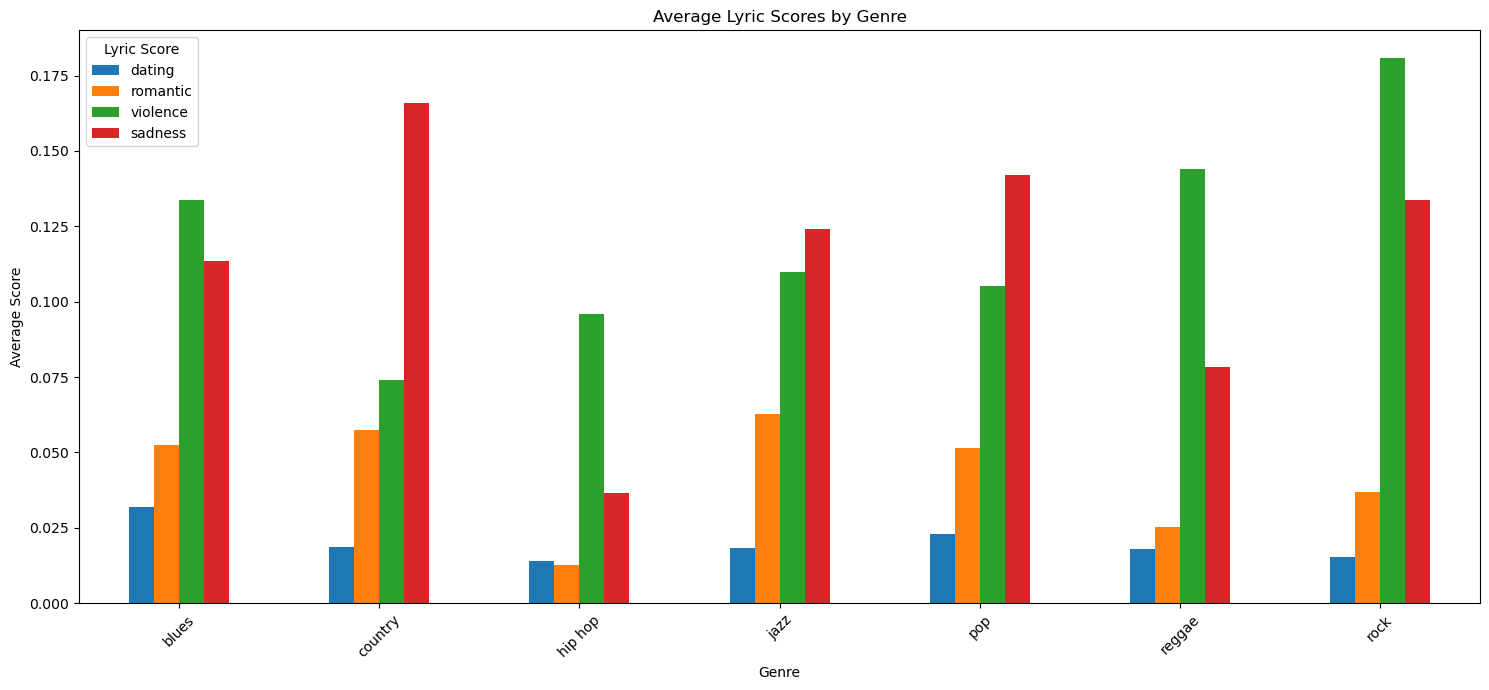

In [49]:
#Lets explore the average lyric scores by genre
#Here we will use a grouped barchart to visualize the average lyric scores for each genre. We will calculate the mean of each lyric score feature for each genre and then plot them.

#First lets pick a few interesting columns for comparison
cols_to_compare = ['dating', 'romantic', 'violence', 'sadness']

#Now we group by genre and taje the mean of each of these columns
genre_means = df.groupby('genre')[cols_to_compare].mean()

#Then we plot the grouped barchart

genre_means.plot(kind='bar', figsize=(15, 7))
plt.title('Average Lyric Scores by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Lyric Score')
plt.tight_layout()
plt.show()

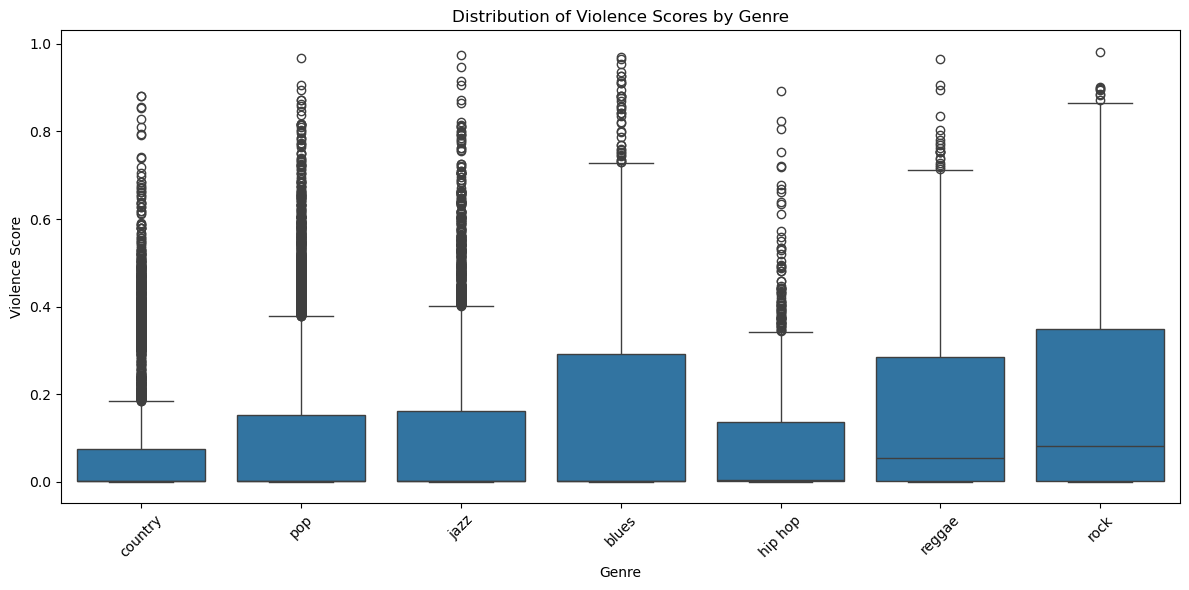

In [50]:
#Now lets explore violence score by genre. Curious to see whether genres are genuinely different or if they overlap alot.

plt.figure(figsize=(12, 6))

#sorting genres by median violence score for better visualization
genre_order = df.groupby('genre')['violence'].median().sort_values().index.tolist()

sns.boxplot(data=df, x='genre', y='violence', order=genre_order)

plt.title('Distribution of Violence Scores by Genre')
plt.xlabel('Genre')
plt.ylabel('Violence Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Multivariate Analysis

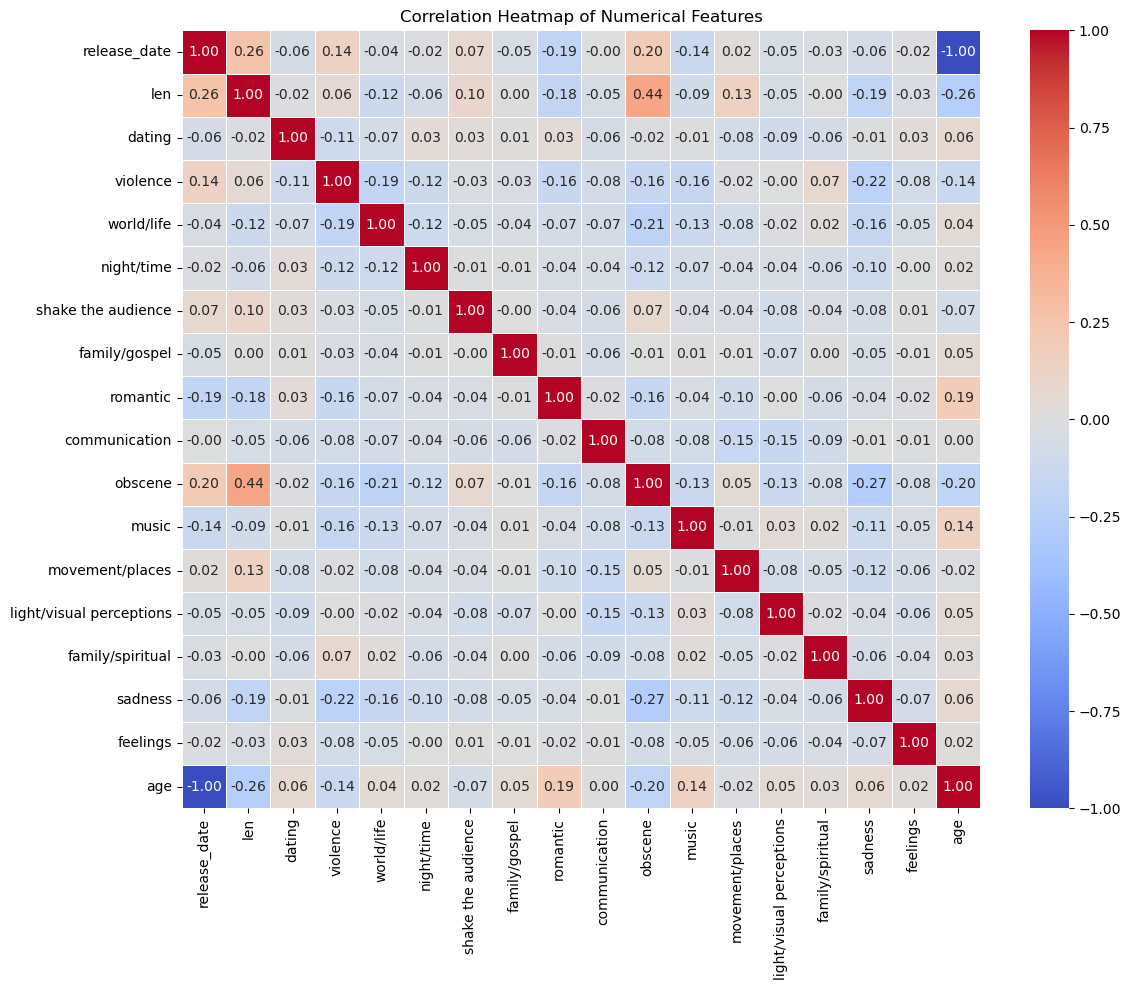

In [51]:
#Now lets create a correlation heatmap to show which columns relate to each other the most. This can help us understand which features are most closely related and may be important for our recommendation algorithm.

#Lets compute the correlation matrix for the numerical features in the dataset
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

#Now we will create a heatmap to visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [53]:
#Let us single out the most correlated pairs so its easier to see which features are most closely related. We will set a threshold for correlation and then print out the pairs of features that have a correlation above that threshold.

#Get the upper triangle of the correlation matrix to avoid duplicate pairs
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

#stack into series , sort by absolute value of correlation, and filter by threshold
corr_pairs = upper_triangle.stack().reset_index().rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'correlation'})

corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values(by='abs_correlation', ascending=False)

print('Top 15 most correlated feature pairs:')
print(corr_pairs.head(15).to_string(index=False))

print("\nPairs with |r| > 0.7 (strong correlation):")
strong_corr_pairs = corr_pairs[corr_pairs['abs_correlation'] > 0.7]
print(strong_corr_pairs.to_string(index=False))


Top 15 most correlated feature pairs:
   Feature_1  Feature_2  correlation  abs_correlation
release_date        age    -1.000000         1.000000
         len    obscene     0.438449         0.438449
     obscene    sadness    -0.266126         0.266126
release_date        len     0.261223         0.261223
         len        age    -0.261223         0.261223
    violence    sadness    -0.221078         0.221078
  world/life    obscene    -0.211483         0.211483
release_date    obscene     0.196165         0.196165
     obscene        age    -0.196165         0.196165
         len    sadness    -0.191908         0.191908
release_date   romantic    -0.191297         0.191297
    romantic        age     0.191297         0.191297
    violence world/life    -0.186943         0.186943
         len   romantic    -0.175072         0.175072
    violence    obscene    -0.159645         0.159645

Pairs with |r| > 0.7 (strong correlation):
   Feature_1 Feature_2  correlation  abs_correlation
r

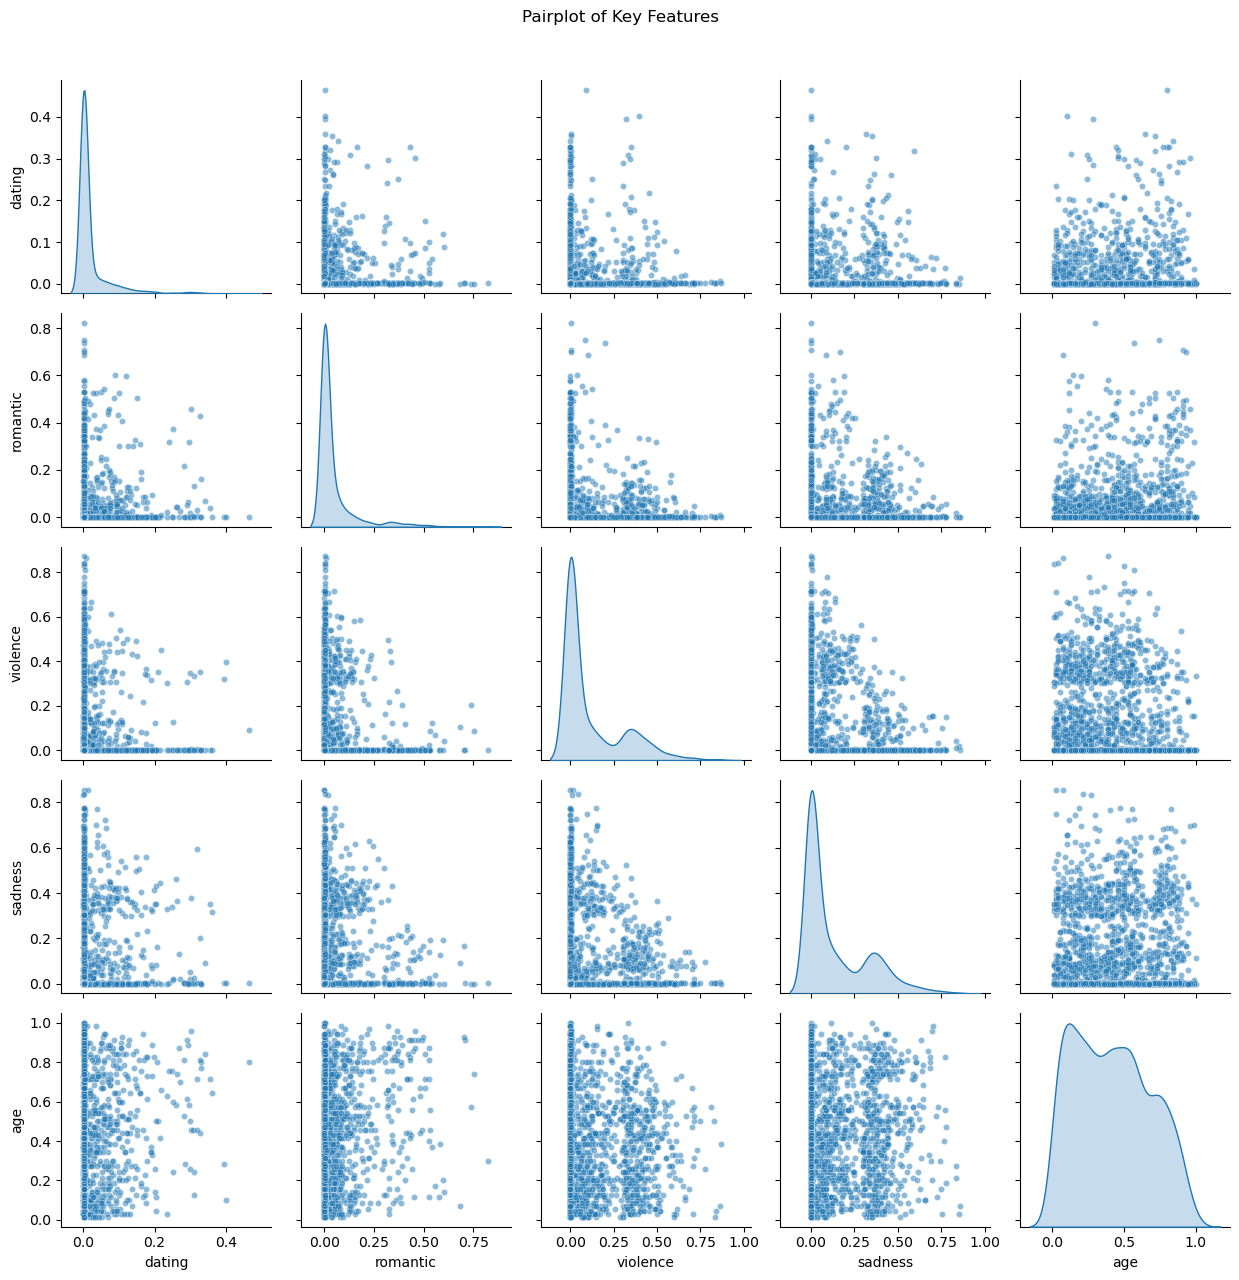

In [54]:
# Now lets create a pairplot to visualize key features and how they relate to each other. We will select a few key features that we think are important for our recommendation algorithm and create a pairplot to visualize the relationships between these features.
# We will limit to 5 columns and a sample of 2000 rows for better visualization.

#Sample 2000 rows for better visualization
df_sample = df.sample(n=2000, random_state=42)

#choosing 5 key features for the pairplot
features_for_pairplot = ['dating', 'romantic', 'violence', 'sadness', 'age']

sns.pairplot(df_sample[features_for_pairplot], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.tight_layout()
plt.show()  

---
## EDA Summary
At the end of our EDA, we found that;
- The dataset contains ~28,000 songs spanning 7+ genres from 1950 to 2019
- The lyric score columns are right-skewed (most songs score low on any given theme)
- Genres do show different lyric score profiles (rock is more violent, gospel is more spiritual)